In [ ]:
import os
import sys
## mundur path satu folder dari folder ipynb
sys.path.insert(0, os.path.abspath(".."))
from src.usgs_downloader import usgs_downloader


In [11]:
BBOX_UTAH_FORGE = {
    "min_lat": 38.45,
    "max_lat": 38.53,
    "min_lon": -113.00,
    "max_lon": -112.85,
    "start_time": "2020-01-01",
    "end_time": "2025-12-31" # Menyesuaikan rentang waktu pengamatan berkala
}

In [ ]:
## Downloader data gempa USGS

try : 
    df_microseis = usgs_downloader(
        bbox = BBOX_UTAH_FORGE,min_mag=0.0,max_mag=3.0
    )
    df_microseis = df_microseis.rename(columns={"mag":"magnitudo"})
    df_microseis.to_csv(
        "../data/raw/katalog_FORGE_2020_2025", index=False
    ) 
except Exception as e:
    print(f"Tidak bisa mengunduh data gempa karena : {e}")

[USGS DOWNLOAD] Menghubungi server USGS Earthquake API...
[USGS DOWNLOAD] Sukses! Terunduh 1,854 event gempa mikro (Mw 0.0 s.d 3.0).


## Pipeline Processing HDBSCAN untuk clustering

In [47]:
## Import module untuk processing HDBSCAN

from src import *

In [18]:
# Path ke file voxel MT asli
mt_raw_path = r"../data/raw/MT Model/FRG200614_mdl17_cellcenter.dat"

# Batas potong reservoir saklek keinginanmu
Z_MIN = -3000
Z_MAX = 1000

print("[INFO] Membaca data inversi 3D MT mentah...")
# skiprows melompati teks deskripsi di header file aslimu
df_mt_raw = pd.read_csv(
    mt_raw_path,
    sep=r"\s+",
    skiprows=[0, 1, 2],
    names=["Y", "X", "Z", "Resistivity"],
)

print(
    f"[FILTER] Memotong elevasi grid MT pada rentang saklek: {Z_MIN} m s.d {Z_MAX} m..."
)
df_mt_filtered = df_mt_raw[df_mt_raw["Z"].between(Z_MIN, Z_MAX)].copy()

print(f"[SUCCESS] Slicing selesai!")
print(
    f"-> Jumlah voxel mentah awal: {len(df_mt_raw):,} baris."
)
print(
    f"-> Jumlah voxel lolos saringan: {len(df_mt_filtered):,} baris."
)

[INFO] Membaca data inversi 3D MT mentah...
[FILTER] Memotong elevasi grid MT pada rentang saklek: -3000 m s.d 1000 m...
[SUCCESS] Slicing selesai!
-> Jumlah voxel mentah awal: 1,094,940 baris.
-> Jumlah voxel lolos saringan: 240,402 baris.


In [19]:
# Menetapkan nama file baru di folder processed
output_dat = "../data/processed/voxel_mt_input.dat"
output_xyz = "../data/processed/voxel_mt_input.xyz"

# Ekspor ke file teks berbasis spasi (tanpa menyertakan indeks baris Pandas)
df_mt_filtered.to_csv(output_dat, sep=" ", index=False)
df_mt_filtered.to_csv(output_xyz, sep=" ", index=False)

print("==================== VERIFIKASI AKHIR DATASET ====================")
print("Elevasi Tertinggi yang tersisa :", df_mt_filtered["Z"].max(), "meter")
print("Elevasi Terendah yang tersisa  :", df_mt_filtered["Z"].min(), "meter")
print("==================================================================")
print(f"[CHECKPOINT] File sukses dibuat:\n-> {output_dat}\n-> {output_xyz}")
print(
    "\nSiap digunakan untuk pengerjaan pipeline model HDBSCAN milikmu!"
)

==================== VERIFIKASI AKHIR DATASET ====================
Elevasi Tertinggi yang tersisa : 999.9943 meter
Elevasi Terendah yang tersisa  : -2999.871 meter
[CHECKPOINT] File sukses dibuat:
-> ../data/processed/voxel_mt_input.dat
-> ../data/processed/voxel_mt_input.xyz

Siap digunakan untuk pengerjaan pipeline model HDBSCAN milikmu!


### Conditioning Data Sebelum Processing

In [20]:
### import modul conditioning data dari src

from src import(
    transform_mt_log_res,
    convert_eq_coordinates,
    map_points_to_voxel_grid
)

In [25]:
## Definisikan direktori folder

path_voxel = "../data/processed/voxel_mt_input.dat"
path_gempa = "../data/raw/katalog_FORGE_2020_2025.csv"

In [32]:
## Load data MT

df_mt = pd.read_csv(path_voxel, sep=" ")
print("data MT sudah di load ")

## conditioning data MT
### Karena data MT rentangnya gede banget dari 10^-1 - 10^3, dijadiin log dulu
df_mt_conditioned = transform_mt_log_res(df_mt)
print("Data MT sudah di conditioning")

data MT sudah di load 
[CONDITIONING] Melakukan transformasi Log10 pada resistivitas MT...
Data MT sudah di conditioning


In [33]:
## Load data Gempa
df_eq = pd.read_csv(path_gempa)
print("Data Gempa sudah di load")

## Transform CRS data Gempa
### Karena data gempa pake long lat , jadiin UTM biar sama kaya MT
df_eq_projected_UTM12N = convert_eq_coordinates(df_eq,utm_zone=12,hemisphere="N")
print("Data Gempa sudah oke")

Data Gempa sudah di load
[CONDITIONING] Mengonversi koordinat gempa ke UTM Zone 12N...
Data Gempa sudah oke


In [74]:
## Conditioning data gempa -> voxel grid
### Hal ini karena data gempa itu data point, bukan grid voxel nanti algoritmanya susah memprediksi
### Jadi data points dijadiin voxel biar sama dimensinya
radius_gempa_meter = 1000
print(f"Conditioning data Gempa menjadi Grid Voxel berdasarkan jarak : {radius_gempa_meter}")

df_combined = map_points_to_voxel_grid(
    df_mt_conditioned,
    df_eq_projected_UTM12N,
    radius_meters=radius_gempa_meter
)

print("Data berhasil diikatkan, voxel sekarang memiliki informasi seis_dens")
print(f"Total voxel yang akan diclustering sejumlah : {len(df_combined)}")

## Tambahan
### Karena nilai seis_dense yang kecil banget -> pakenya log seis_dense

df_combined['log_seis_dens'] = log10_safe(df_combined['seismic_density'])
min_val = df_combined['log_seis_dens'].min()
df_combined['log_seis_dens'] = df_combined['log_seis_dens'].fillna(min_val)

print(df_combined['log_seis_dens'].describe())

Conditioning data Gempa menjadi Grid Voxel berdasarkan jarak : 1000
[CONDITIONING] Grid alignment: menghitung gempa dalam radius 1000m per voxel...
[CONDITIONING] Selesai. Max event dalam satu voxel: 712 event.
Data berhasil diikatkan, voxel sekarang memiliki informasi seis_dens
Total voxel yang akan diclustering sejumlah : 240402
count    240402.000000
mean         -9.602081
std           0.170355
min          -9.622089
25%          -9.622089
50%          -9.622089
75%          -9.622089
max          -6.769609
Name: log_seis_dens, dtype: float64


In [86]:
### Data sudah terkondisikan
### Lanjut ke feature yang mau diclustering
feature_cols = ["X","Y","Z","log_res"]
spatial_weight = 1.0

### Menyiapkan array untuk clustering
X_Scaled, scaler = scale_features(df_combined,feature_cols, spatial_weight)
print(f"Shape input ke HDBSCAN : {X_Scaled.shape}")

[MODEL] Standardisasi fitur dengan StandardScaler...
Shape input ke HDBSCAN : (240402, 4)


In [108]:
### Mainline HDBSCAN clustering
### Disini cluster dibuat berdasarkan perhitungan HDBSCAN
### min_cluster_size = minimum voxel yang diclustering 
### min_samples = minimum sample yang ada dalam satu cluster
labels, clusterer = run_hdbscan(X_Scaled, min_cluster_size=3000, min_samples=10)
df_combined["cluster_labels"] = labels

[MODEL] HDBSCAN (min_cluster_size=3000, min_samples=10)...
[MODEL] Hasil: 5 klaster ditemukan, 93581 titik noise.


In [109]:
### Lihat statistik cluster

stats = df_combined.groupby("cluster_labels")[["log_res", "seismic_density"]].mean().round(4)
stats["jumlah_voxel"] = df_combined.groupby("cluster_labels")["log_res"].count()
stats["pct_total"] = (stats["jumlah_voxel"] / len(df_combined) * 100).round(2)
print(stats.sort_values("seismic_density", ascending=False))

                log_res  seismic_density  jumlah_voxel  pct_total
cluster_labels                                                   
-1               2.0916              0.0         93581      38.93
 0               2.8522              0.0         19938       8.29
 1               2.7107              0.0         16792       6.98
 2               2.7665              0.0          4565       1.90
 3               2.5669              0.0         14880       6.19
 4               1.9904              0.0         90646      37.71


[PLOT] Penampang 2D slice X=335450m...
Sumur di luar range: []


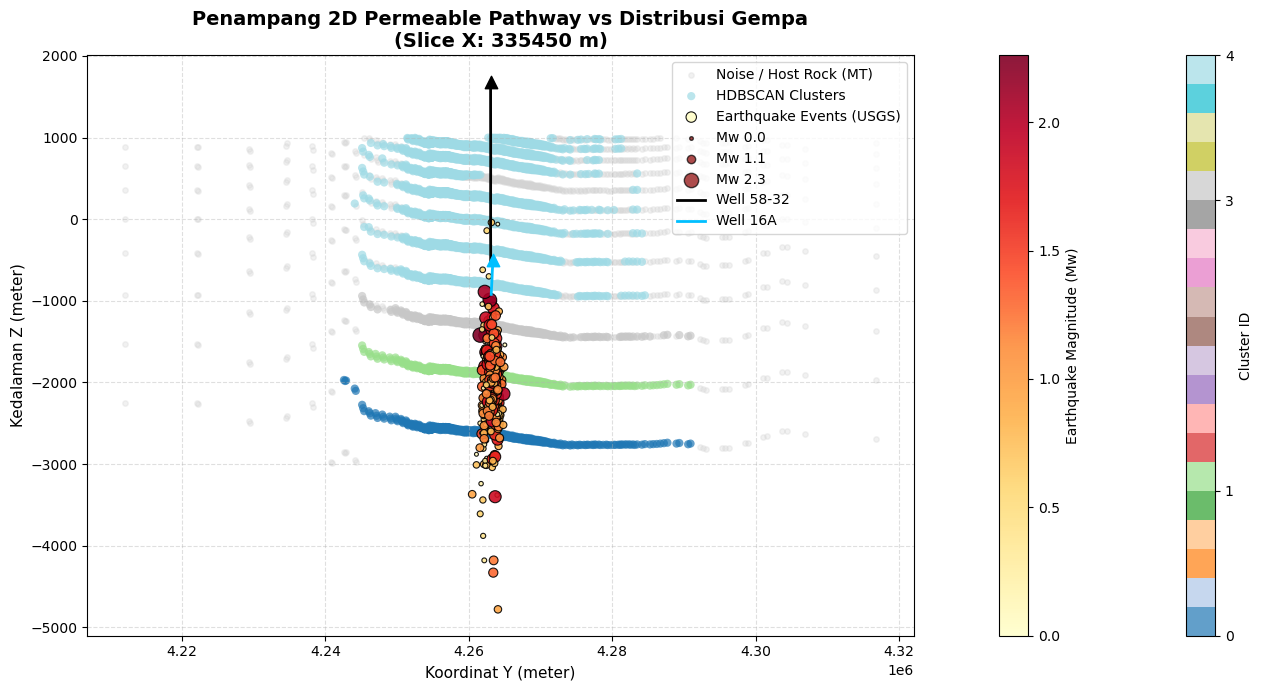

In [116]:
wells = [
    {
        "path": "../data/raw/well_path_5832.csv",
        "name": "Well 58-32",
        "wellhead_x": 335450.9891,
        "wellhead_y": 4263037.906,
        "wellhead_elev_m": 1684.77,  # dari tabel, konversi 5527ft
    },
    {
        "path": "../data/raw/well_path_16A.csv",
        "name": "Well 16A",
        "wellhead_x": 334641.1891,
        "wellhead_y": 4263443.693,
        "wellhead_elev_m": 1684.77,
    },
]

fig, out_of_range = plot_2d_slice_with_eq(
    df_combined,
    df_eq_projected_UTM12N,
    slice_coord=335450,
    tolerance=500,
    slice_by="X",
    x_axis="Y",
    z_axis="Z",
    eq_mag_col="magnitudo",
    global_mag_min=df_eq_projected_UTM12N['magnitudo'].min(),
    wells=wells,
)

print("Sumur di luar range:", out_of_range)

In [115]:
import importlib
import src.plots.cross_section as cs
importlib.reload(cs)
from src.plots.cross_section import plot_2d_slice_with_eq

In [113]:
FT_TO_M = 0.3048

df_5832 = pd.read_csv("../data/raw/well_path_5832.csv")
x_5832 = 335450.9891 + df_5832["E"] * FT_TO_M
y_5832 = 4263037.906 + df_5832["N"] * FT_TO_M

print("58-32 X range:", x_5832.min(), "-", x_5832.max())
print("58-32 Y range:", y_5832.min(), "-", y_5832.max())

58-32 X range: 335401.21526 - 335452.57406
58-32 Y range: 4263037.906 - 4263048.817840001
